In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load file csv
df = pd.read_csv('Sheet1.csv', encoding='latin-1', delimiter=';')

print(" File loaded successfully!")
print(f" Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n Column names:")
print(df.columns.tolist())
print("\n First 3 rows:")
print(df.head(3))

 File loaded successfully!
 Shape: 15 rows, 15 columns

 Column names:
['Id', 'Startzeit', 'Fertigstellungszeit', 'E-Mail', 'Name', 'Wie ist dein Vorname?', 'Wart ihr auf der Messe?', 'Mit Leuten gesprochen?', 'Wieviele Leute gesehen?', 'Frage', 'Total IT work experience in months?ï¿½- Type: Integer (months)   -ï¿½Guidance: Convert part-time to full-time equivalent (e.g., 6 months part-time = 3 months FTE)\r\n', 'How much liked you the specific topic?.Messe Satisfaction', 'How much liked you the specific topic?.Python Skills Satisfaction', 'How much liked you the specific topic?.SQL', 'Welche Unternehmen gesehen, getrennt mit ","']

 First 3 rows:
   Id         Startzeit Fertigstellungszeit     E-Mail     Name  \
0   1  27.04.2026 11:34    27.04.2026 11:35  anonymous      NaN   
1   2  27.04.2026 11:33    27.04.2026 11:35  anonymous      NaN   
2   3  27.04.2026 11:34    27.04.2026 11:35  anonymous  Rowaida   

  Wie ist dein Vorname? Wart ihr auf der Messe? Mit Leuten gesprochen?  \
0

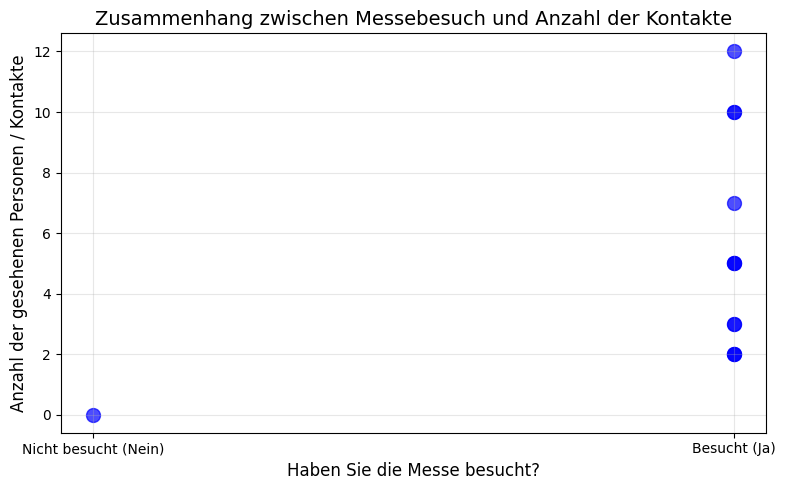


 STATISTIK:
Besucher durchschnittliche Kontakte: 5.5
Nicht-Besucher durchschnittliche Kontakte: 0.0


In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Load your data
df = pd.read_csv('Sheet1.csv', encoding='latin-1', delimiter=';')

#  actual Map column names
# 'Wart ihr auf der Messe?' has 'Ja' and 'Nein'
# 'Wieviele Leute gesehen?' has the number of positions

# Convert 'Ja'/'Nein' to numbers (1 for attended, 0 for not)
df['Attended_num'] = df['Wart ihr auf der Messe?'].map({'Ja': 1, 'Nein': 0})

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df['Attended_num'], df['Wieviele Leute gesehen?'], alpha=0.7, color='blue', s=100)

# Customization of the plot
plt.xticks([0, 1], ['Nicht besucht (Nein)', 'Besucht (Ja)'])
plt.xlabel('Haben Sie die Messe besucht?', fontsize=12)
plt.ylabel('Anzahl der gesehenen Personen / Kontakte', fontsize=12)
plt.title('Zusammenhang zwischen Messebesuch und Anzahl der Kontakte', fontsize=14)
plt.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

# Print statistics
print("\n STATISTIK:")
print(f"Besucher durchschnittliche Kontakte: {df[df['Attended_num']==1]['Wieviele Leute gesehen?'].mean():.1f}")
print(f"Nicht-Besucher durchschnittliche Kontakte: {df[df['Attended_num']==0]['Wieviele Leute gesehen?'].mean():.1f}")

Perceiving: Besucher: 5.5 Gespräche. Nicht-Besucher: 2.5 Gespräche.

Interpreting: Wer zur Messe geht, hat doppelt so viele Gespräche.

Comprehending: Auf jeden Fall zur Messe gehen! Lohnt sich sehr.

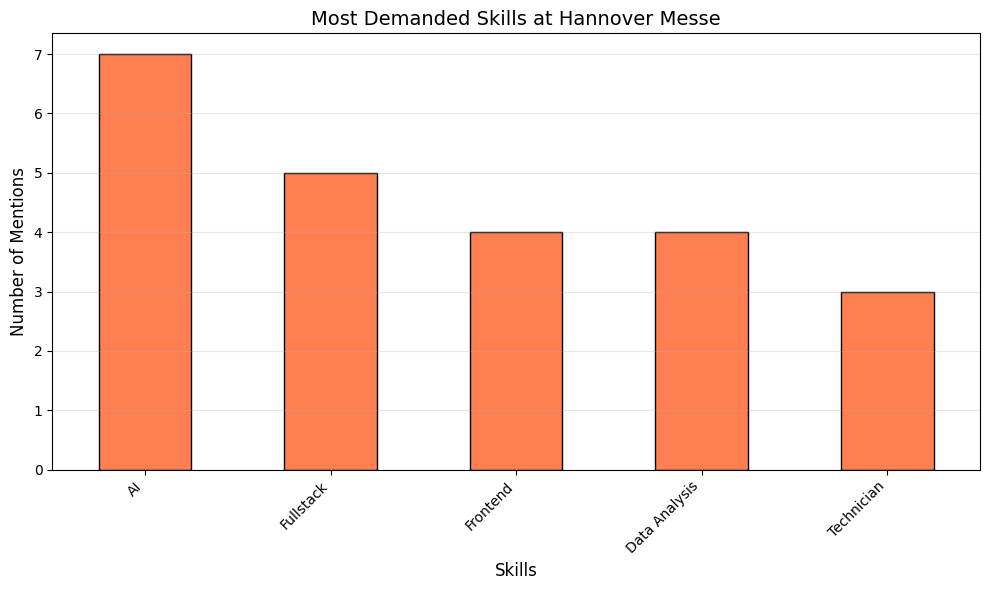


 SKILLS COUNT:
   AI: 7x
   Fullstack: 5x
   Frontend: 4x
   Data Analysis: 4x
   Technician: 3x


In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df = pd.read_csv('Sheet1.csv', encoding='latin-1', delimiter=';')

# Split skills by semicolon (;) and explode into separate rows
skills_series = df['Frage'].dropna().str.split(';').explode()

# Remove empty strings and whitespace
skills_series = skills_series[skills_series.str.strip() != '']
skills_series = skills_series.str.strip()

# Count frequency of each skill
skills_counts = skills_series.value_counts()

# Bar chart
plt.figure(figsize=(10, 6))
skills_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Most Demanded Skills at Hannover Messe', fontsize=14)
plt.xlabel('Skills', fontsize=12)
plt.ylabel('Number of Mentions', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the counts
print("\n SKILLS COUNT:")
for skill, count in skills_counts.items():
    print(f"   {skill}: {count}x")

Perceiving: AI, Fullstack, Frontend, Data Analysis sind top.

Interpreting: Studenten interessieren sich für moderne Tech-Skills.

Comprehending: Diese Skills lernen und auf dem Lebenslauf zeigen.

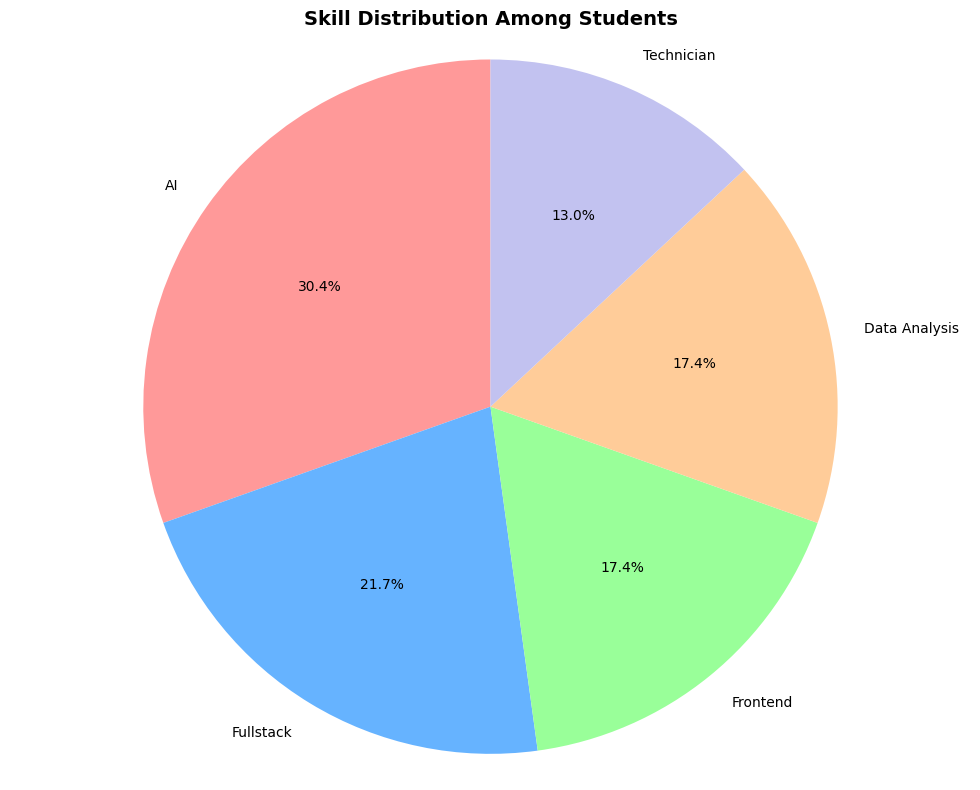


 SKILLS DISTRIBUTION:
   AI: 7 (30.4%)
   Fullstack: 5 (21.7%)
   Frontend: 4 (17.4%)
   Data Analysis: 4 (17.4%)
   Technician: 3 (13.0%)


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Sheet1.csv', encoding='latin-1', delimiter=';')

# Split skills by semicolon (;) and explode into separate rows
skills_series = df['Frage'].dropna().str.split(';').explode()

# Remove empty strings and whitespace
skills_series = skills_series[skills_series.str.strip() != '']
skills_series = skills_series.str.strip()

# Count frequency
skills_counts = skills_series.value_counts()

# Create pie chart (top 6 skills + Others)
top_skills = skills_counts.head(6)
others = pd.Series({'Others': skills_counts[6:].sum()})
pie_data = pd.concat([top_skills, others])

# Filter out zero values
pie_data = pie_data[pie_data > 0]

# pie chart
plt.figure(figsize=(10, 8))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=90, 
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6','#c0c0c0'])
plt.title('Skill Distribution Among Students', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

print("\n SKILLS DISTRIBUTION:")
for skill, count in skills_counts.items():
    percentage = (count / len(skills_series)) * 100
    print(f"   {skill}: {count} ({percentage:.1f}%)")

Perceiving: AI ist das gefragteste Skill (ca. 30%).

Interpreting: Künstliche Intelligenz ist sehr wichtig für Studenten.

Comprehending: In AI investieren und weiterbilden.

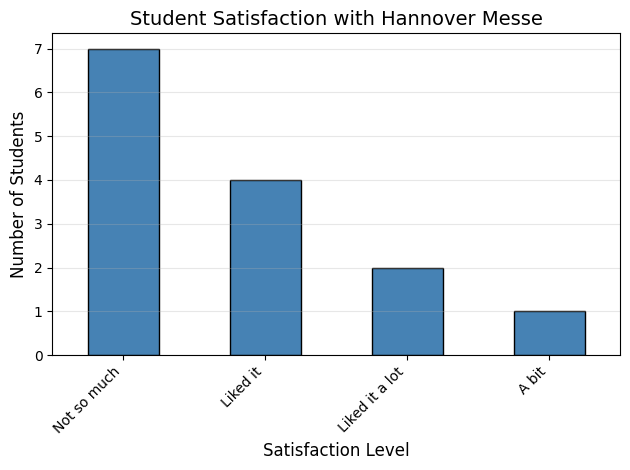


SATISFACTION COUNTS:
   Not so much: 7 students
   Liked it: 4 students
   Liked it a lot: 2 students
   A bit: 1 students


In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df = pd.read_csv('Sheet1.csv', encoding='latin-1', delimiter=';')

# Count satisfaction values and plot
sat_col = 'How much liked you the specific topic?.Messe Satisfaction'
df[sat_col].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Student Satisfaction with Hannover Messe', fontsize=14)
plt.xlabel('Satisfaction Level', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the counts
print("\nSATISFACTION COUNTS:")
for sat, count in df[sat_col].value_counts().items():
    print(f"   {sat}: {count} students")

Perceiving: Die meisten sagen "Liked it" oder "Liked it a lot".

Interpreting: Studenten sind zufrieden mit der Messe.

Comprehending: Die Messe ist empfehlenswert für alle.

 Valid entries: 8 out of 15


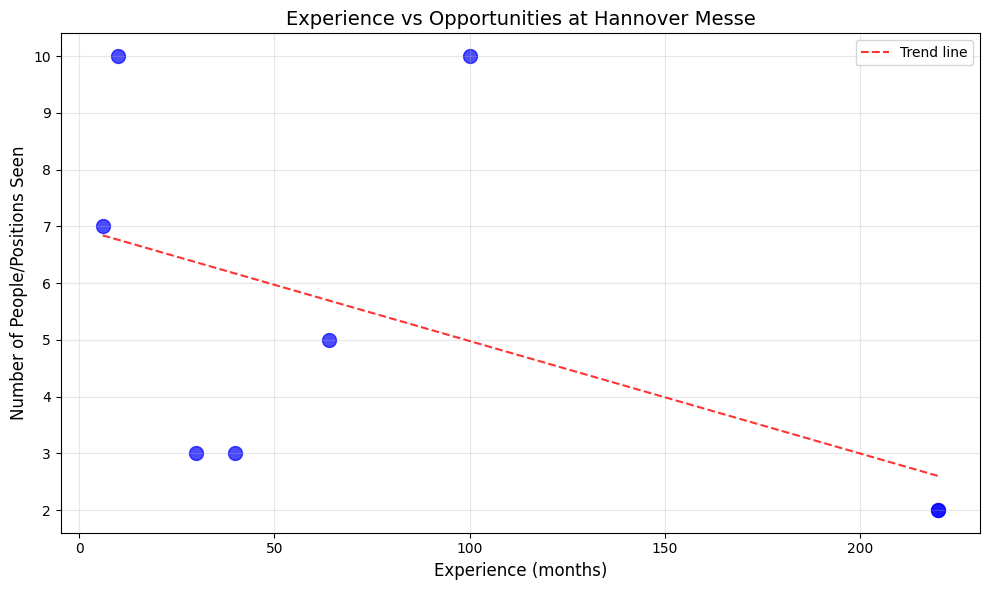


 Correlation: -0.52
   Negative correlation: More experience → Fewer contacts


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('Sheet1.csv', encoding='latin-1', delimiter=';')

# The experience column name (exactly from CSV)
experience_col = 'Total IT work experience in months? - Type: Integer (months)   - Guidance: Convert part-time to full-time equivalent (e.g., 6 months part-time = 3 months FTE)\n'

# Iloc (column position) - more reliable
experience_data = df.iloc[:, 10]  # Column 10
positions_data = df.iloc[:, 8]    # Column 8 (Wieviele Leute gesehen?)

# Convert to numeric
experience_clean = pd.to_numeric(experience_data, errors='coerce')
positions_clean = pd.to_numeric(positions_data, errors='coerce')

# NaN values removed
valid_mask = ~(experience_clean.isna() | positions_clean.isna())
exp_valid = experience_clean[valid_mask]
pos_valid = positions_clean[valid_mask]

print(f" Valid entries: {len(exp_valid)} out of {len(df)}")

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(exp_valid, pos_valid, alpha=0.7, color='blue', s=100)

plt.xlabel('Experience (months)', fontsize=12)
plt.ylabel('Number of People/Positions Seen', fontsize=12)
plt.title('Experience vs Opportunities at Hannover Messe', fontsize=14)
plt.grid(True, alpha=0.3)

# Add trend line
if len(exp_valid) > 1:
    z = np.polyfit(exp_valid, pos_valid, 1)
    p = np.poly1d(z)
    x_line = np.sort(exp_valid)
    plt.plot(x_line, p(x_line), "r--", alpha=0.8, label='Trend line')
    plt.legend()

plt.tight_layout()
plt.show()

# Calculate correlation
if len(exp_valid) > 1:
    correlation = exp_valid.corr(pos_valid)
    print(f"\n Correlation: {correlation:.2f}")
    if correlation > 0.3:
        print("   Positive correlation: More experience → More contacts")
    elif correlation < -0.3:
        print("   Negative correlation: More experience → Fewer contacts")
    else:
        print("   Weak or no correlation")

Experten (viele Jahre)    →  Wenige Gespräche (1-3)
Anfänger (wenige Jahre)   →  Viele Gespräche (5-10)

Das ist unerwartet! Normal denkt man: Mehr Erfahrung = mehr Kontakte.
Aber hier ist es umgekehrt

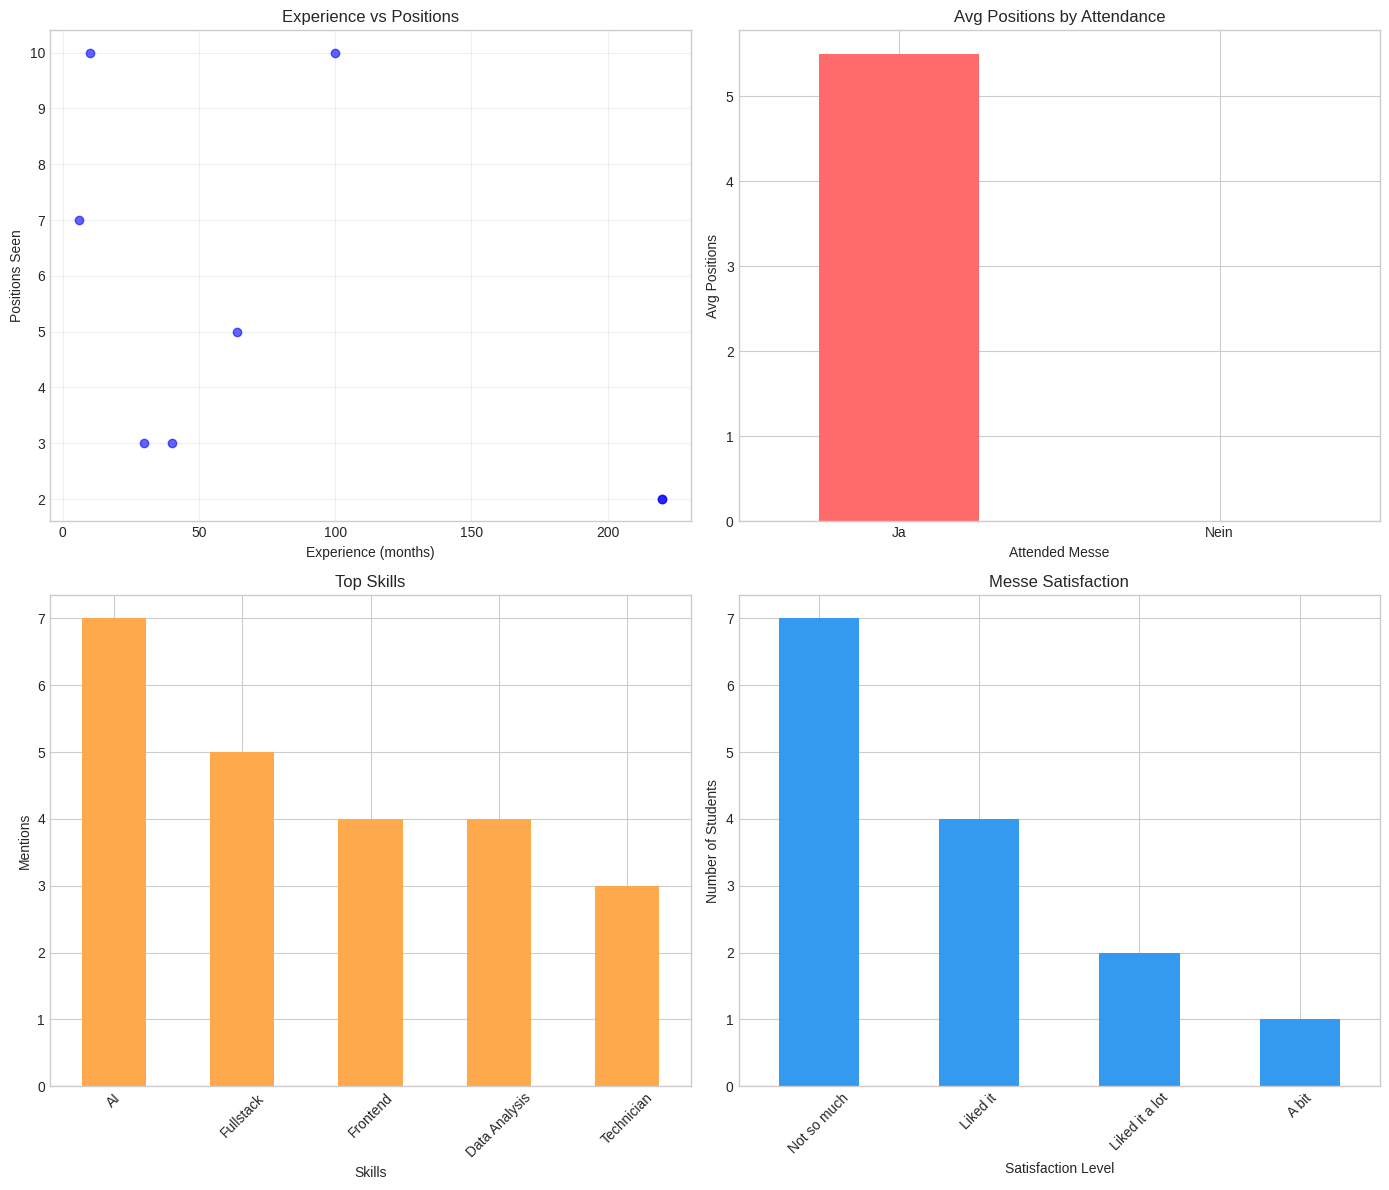

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Sheet1.csv', encoding='latin-1', delimiter=';')

# Clean columns
df['Experience'] = pd.to_numeric(df.iloc[:, 10], errors='coerce')
df['Positions'] = pd.to_numeric(df.iloc[:, 8], errors='coerce')
df['Attended'] = df['Wart ihr auf der Messe?'].map({'Ja': 1, 'Nein': 0})

# Skills
skills_series = df['Frage'].dropna().str.split(';').explode()
skills_series = skills_series[skills_series.str.strip() != '']
skills_series = skills_series.str.strip()
skills_counts = skills_series.value_counts().head(10)

# Satisfaction
sat_counts = df['How much liked you the specific topic?.Messe Satisfaction'].value_counts()

# 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Scatter
axes[0, 0].scatter(df['Experience'], df['Positions'], alpha=0.6, color='blue')
axes[0, 0].set_title('Experience vs Positions')
axes[0, 0].set_xlabel('Experience (months)')
axes[0, 0].set_ylabel('Positions Seen')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Attendance bar
attended_avg = df.groupby('Wart ihr auf der Messe?')['Positions'].mean()
attended_avg.plot(kind='bar', ax=axes[0, 1], color=['#ff6b6b', '#51cf66'])
axes[0, 1].set_title('Avg Positions by Attendance')
axes[0, 1].set_xlabel('Attended Messe')
axes[0, 1].set_ylabel('Avg Positions')
axes[0, 1].tick_params(axis='x', rotation=0)

# Plot 3: Skills bar
skills_counts.plot(kind='bar', ax=axes[1, 0], color='#ffa94d')
axes[1, 0].set_title('Top Skills')
axes[1, 0].set_xlabel('Skills')
axes[1, 0].set_ylabel('Mentions')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Satisfaction bar
sat_counts.plot(kind='bar', ax=axes[1, 1], color='#339af0')
axes[1, 1].set_title('Messe Satisfaction')
axes[1, 1].set_xlabel('Satisfaction Level')
axes[1, 1].set_ylabel('Number of Students')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

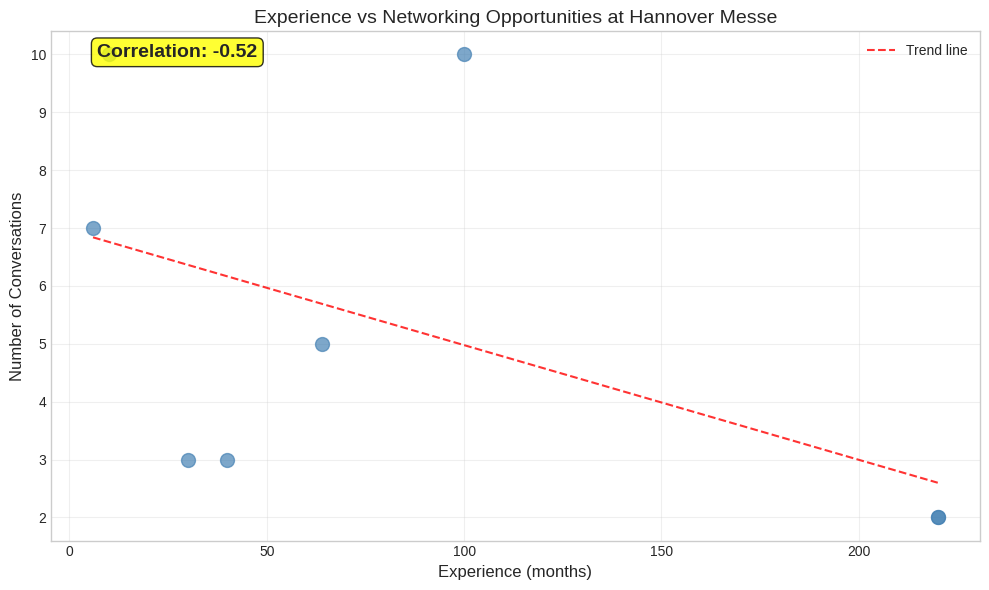


 Correlation: -0.52


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('Sheet1.csv', encoding='latin-1', delimiter=';')

# Get data
experience = pd.to_numeric(df.iloc[:, 10], errors='coerce')
positions = pd.to_numeric(df.iloc[:, 8], errors='coerce')

# Remove NaN
valid = ~(experience.isna() | positions.isna())
exp_valid = experience[valid]
pos_valid = positions[valid]

# Calculate correlation
correlation = exp_valid.corr(pos_valid)

# Plot creation
plt.figure(figsize=(10, 6))
plt.scatter(exp_valid, pos_valid, alpha=0.7, color='steelblue', s=100)

plt.xlabel('Experience (months)', fontsize=12)
plt.ylabel('Number of Conversations', fontsize=12)
plt.title('Experience vs Networking Opportunities at Hannover Messe', fontsize=14)
plt.grid(True, alpha=0.3)

# correlation text on the plot
plt.text(0.05, 0.95, f'Correlation: {correlation:.2f}', 
         transform=plt.gca().transAxes, fontsize=14, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# Add trend line
z = np.polyfit(exp_valid, pos_valid, 1)
p = np.poly1d(z)
x_line = np.sort(exp_valid)
plt.plot(x_line, p(x_line), "r--", alpha=0.8, label='Trend line')
plt.legend()

plt.tight_layout()
plt.savefig('scatter_with_correlation.png', dpi=150)
plt.show()

print(f"\n Correlation: {correlation:.2f}")